In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import math
import pickle
import os
from scipy.optimize import minimize
from scipy.optimize import fsolve
from scipy.interpolate import interp1d
from astropy.cosmology import Planck18
import importlib
from scipy.interpolate import UnivariateSpline
from scipy import integrate
from scipy.optimize import root_scalar

import halo_and_cluster_MF as hcmf
import useful_functions as uf

cosmo = Planck18


In [23]:
path_eRASS1 = '../DESI_eRass/eRass_Bulbul_2024.fit' #la première table est la table eRosita de départ, enrichie avec des informations d'association avec SDSS-Wen
table_eRASS1 = uf.fits_to_dataframe(path_eRASS1)

In [24]:
## eRASS1
bornes_z_eRASS1 = [0.03,1.32] 
angular_area_eRASS1_deg2 = 13116 # Surface couverte par eRASS1/SDSS/unWISE en degrés carrés
volume_eRASS1 = uf.Volume_survey(angular_area_eRASS1_deg2,bornes_z_eRASS1)

# Calcul $\frac{dn}{dlog_{10}(M_{500})}(M_{500})$

In [25]:
from matplotlib.colors import LinearSegmentedColormap
colors = ["blue", "cyan", "green", "darkorange", "orangered","lightcoral"]


In [26]:
range_log10_M_Msun = np.linspace(12.5,15.5,50) # log10(M500/Msun)
range_z = np.linspace(0.1,2.1,5)

CMF_values_z = []

for z in range_z:
    CMF_values_z.append(hcmf.CMF_Bocquet_2016_log10(10**(range_log10_M_Msun), z))

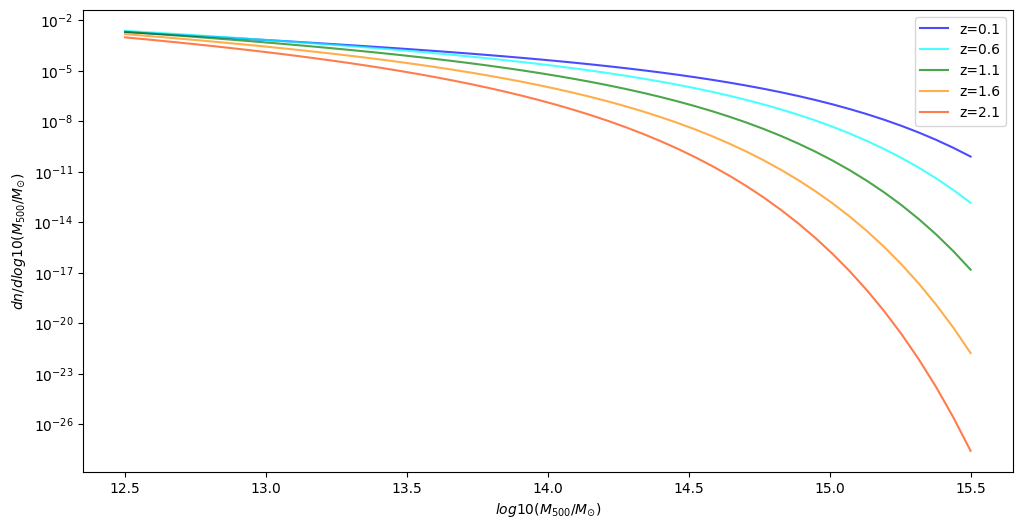

In [27]:
plt.figure(figsize=(12, 6))

for i,ClxF_values in enumerate(CMF_values_z):
    plt.plot(range_log10_M_Msun, CMF_values_z[i], color=colors[i], label = f'z={range_z[i]}' ,alpha=0.7)
    plt.yscale('log')
    plt.xlabel(r'$log10(M_{500}/M_{\odot}$)')
    plt.ylabel(r'$dn / dlog10(M_{500}/M_{\odot})$')

    

plt.legend()

plt.show()

# Définition fonctions utiles
On va les tester pour les modifier

In [ ]:
def M_from_Lx(Lx, z):
    # section 2.3 Maughan et al. 2013
    # Lx : Cluster Luminosity in erg/s, between 0.2 and 2.3 keV
    # z : redshift

    # On commence par passer de Lx (compris entre 0.2 et 2.3 kev) à L_Maughan (correspond à l'entièreté du rayonnement Bremsstrahlung)
    a_coeff = 0.093 ; b_coeff = 0.254
    coeff_Lx_L = (a_coeff * z + b_coeff) # → issu de l'optimisation (voir test_optim_BLM.py)

    L_Maughan = Lx * (1/coeff_Lx_L)


    # Ensuite on utilise la relation d'échelle de Maughan et al. 2013 pour passer de L_Maughan à M500
    # 1) Valeurs : Table 5 Maughan et al. 2018
    A_LM = 0.97 ; A_LM_minus = A_LM - 0.08 ; A_LM_max = A_LM + 0.08
    #B_LM = 1.64 ; B_LM_minus = B_LM - 0.09 ; B_LM_max = B_LM + 0.09
    

    # 2) Valeurs : For self-similar clusters in virial equilibrium :
    #B_LM = 4/3
    gamma_LM = 7/3

    # 3) Valeurs issu de l'optim (voir test_optim_BLM.py):
    #B_LM = 1.476
    a = -0.495 ; b = 1.539
    B_LM = a * z + b


    L_0 = 5*1e44 # erg/s
    M_0 = 5*1e14 # M_sun
    E_z = cosmo.efunc(z)  # E(z) = H(z)/H0

    M = M_0 * ((L_Maughan/L_0) / (A_LM * (E_z)**gamma_LM))**(1/B_LM)

In [ ]:
def CLxF_eRASS_Bocquet_2016(Lx , z):
    # Cluster X-ray luminosity function adapted for eRASS1 using Maughan et al. 2013 and Bocquet et al. 2016 CMF
    # Lx : Cluster Luminosity in erg/s, between 0.2 and 2.3 keV
    # z : redshift

    # Renvoie (dn/dlog10(Lx))(Lx(M500))

    # On commence par calculer (dn/dlog10(M500))(M500) isssu de Bocquet et al. 2016
    M500 = uf.M_from_Lx(Lx,z) #→ utilise Maughan et al. 2013
    dn_dlog10M500 = hcmf.CMF_Bocquet_2016_log10(M500, z)

    # On calcule l'élément différentiel
    a = -0.495 ; b = 1.539
    B_LM = a * z + b

    dlog10M500_dlog10Lx = 1/B_LM

    # On a notre résultat final :
    dn_dlog10Lx = dn_dlog10M500 * dlog10M500_dlog10Lx

    return dn_dlog10Lx

# Calculs valeurs

In [32]:
# Données
LX_eRASS1 = np.array(table_eRASS1['L500']) # 0.2-2.3keV luminosity within R500 at zlambda (10^35 W → 10^42 erg.s^-1)
LX_eRASS1 = LX_eRASS1 * 1e42 # W → erg.s^-1
LX_eRASS1 = LX_eRASS1[(LX_eRASS1 > 0)] # On ne garde que les valeurs stritement positives de luminosité
log10_LX_eRASS1 = np.log10(LX_eRASS1) # log10(LX_eRASS1) in erg.s^-1
ln_LX_eRASS1 = np.log(LX_eRASS1)

bin_centers_LX_eRASS1_log10, counts_LX_eRASS1_log10, bin_width_LX_eRASS_log10, n_LX_eRASS1_log10 = uf.compute_histogram_density(log10_LX_eRASS1,bins=100,volume=volume_eRASS1)
print("Bin width for log10(LX eRASS1):", bin_width_LX_eRASS_log10)

Bin width for log10(LX eRASS1): 0.044988633799981415


In [33]:
#Théorie 
#range_Lx = np.linspace(1e-3 * 1e42,3600 * 1e42,10000) # 10^42 erg.s^-1
range_z = np.arange(0.1, 1.4, 0.3) 

ClxF_values_z = []
for z in range_z:
    ClxF_values_z.append(hcmf.CLxF_eRASS_Bocquet_2016(10**(bin_centers_LX_eRASS1_log10), z))
    

# Tracés

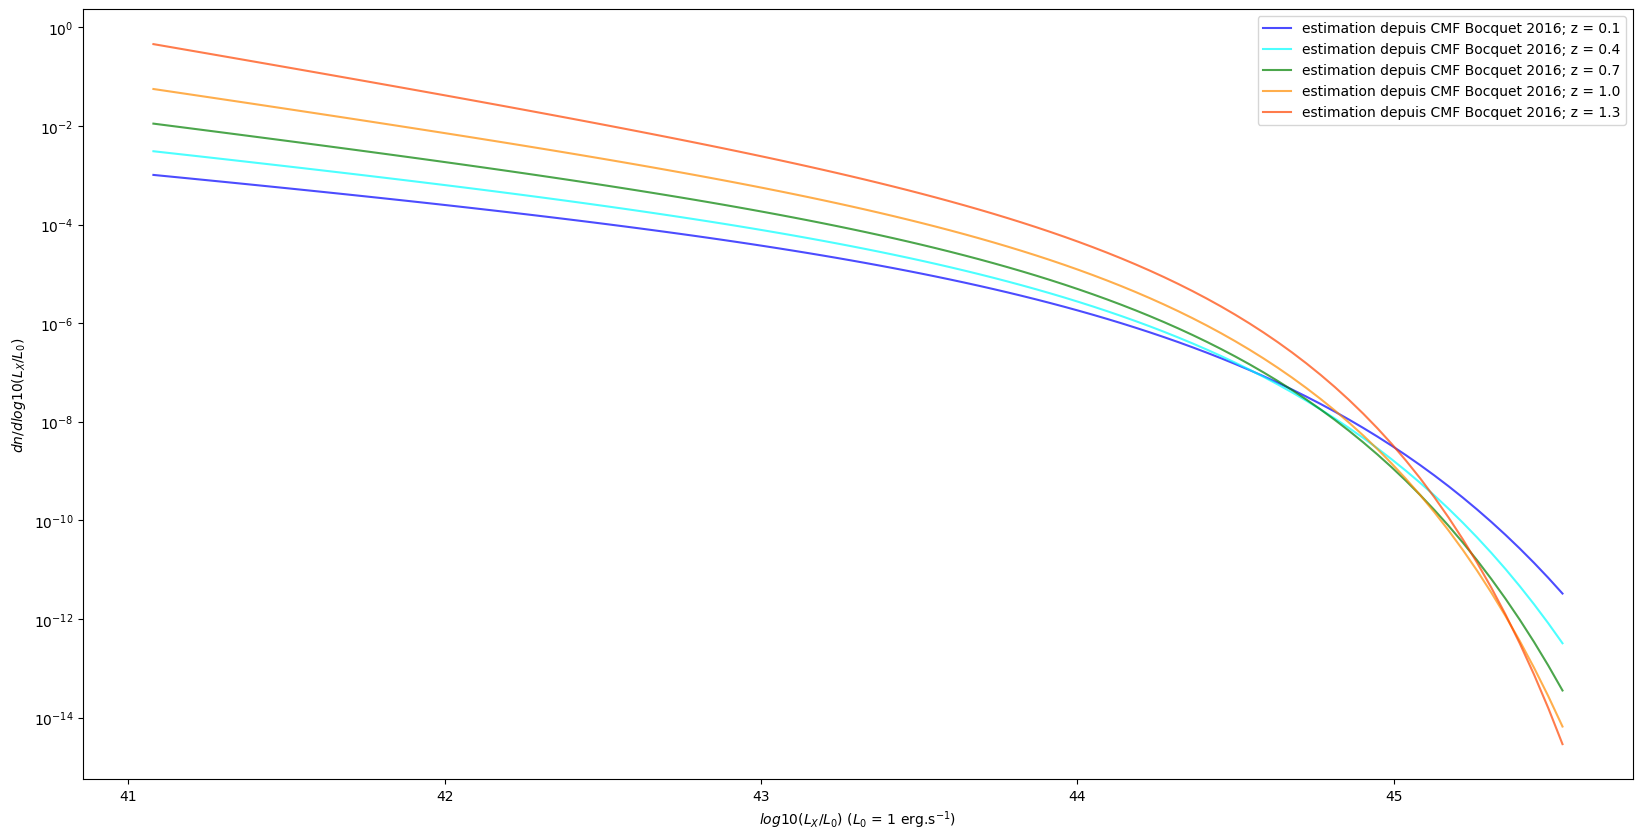

In [35]:
# A comparer avec la théorie de la fonction de luminosité ! → besoin d'une relation d'échelle adaptée à eRASS1
plt.figure(figsize=(20, 10))


for i,ClxF_values in enumerate(ClxF_values_z):
    plt.plot(bin_centers_LX_eRASS1_log10, ClxF_values, color=colors[i], label=f'estimation depuis CMF Bocquet 2016; z = {np.round(range_z[i], 2)}', alpha=0.7)
    plt.xlabel(r'$log10(L_{X}/L_0)$ ($L_0$ = 1 erg.s$^{-1}$)')
    plt.ylabel(r'$dn / dlog10(L_{X}/L_0)$ ')
    plt.yscale('log')

plt.legend()

plt.show()